## 1 - Loading and Inspecting

In [1]:
import pandas as pd
import numpy as np
from sklearn import decomposition
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import altair as alt

df = pd.read_csv('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/data/processed/matrix.csv')

# Fix the sample column anme if it loaded as unnamed
if 'Unnamed:0' in df.columns:
    df.rename(columns={'Unnamed: 0':'Sample'}, inplace=True)

print(f'Loaded matrix: {df.shape[0]} samples x {df.shape[1]} columns')
df.head(3)

Loaded matrix: 1092 samples x 4945 columns


,Sample,rs144366698,rs200391621,rs78888200,rs200049935,rs182808734,rs147783986,rs202082800,rs185745570,rs151231161,...,rs6010062,rs186386126,rs73174436,rs6010073,rs181024981,rs180882000,rs147614277,rs192355741,rs191731586,Population code
0,HG00096,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,GBR
1,HG00097,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,GBR
2,HG00099,0,0,1,0,0,1,0,0,0,...,1,0,0,2,0,0,1,0,0,GBR


## 2 - Separating Genotypes From Metadata

In [2]:
# The non-SNP columns are metadata, not genetic data
non_snp_cols = ['Sample', 'Population code']

# Drop them to get the pure numeric matrix
df_snps = df.drop(columns=non_snp_cols)

# Convert to numpy for scikit-learn
matrix = df_snps.to_numpy()
print(f'SNP matrix shape (samples x variants): {matrix.shape}')


SNP matrix shape (samples x variants): (1092, 4943)


## 3 - Running PCA

In [3]:
# Fit PCA, asking for 2 components (PC1 and PC2)
pca = decomposition.PCA(n_components=2)
pca.fit(matrix)

# How much variance does each component explain?
print('Variance explained:')
print(f' PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f' PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')

# Project every sample into PC space
to_plot = pca.transform(matrix)
print(f'Projected shape: {to_plot.shape}') 


Variance explained:
 PC1: 8.25%
 PC2: 5.41%
Projected shape: (1092, 2)


## 4 - Quick Sanity-Check Scatter

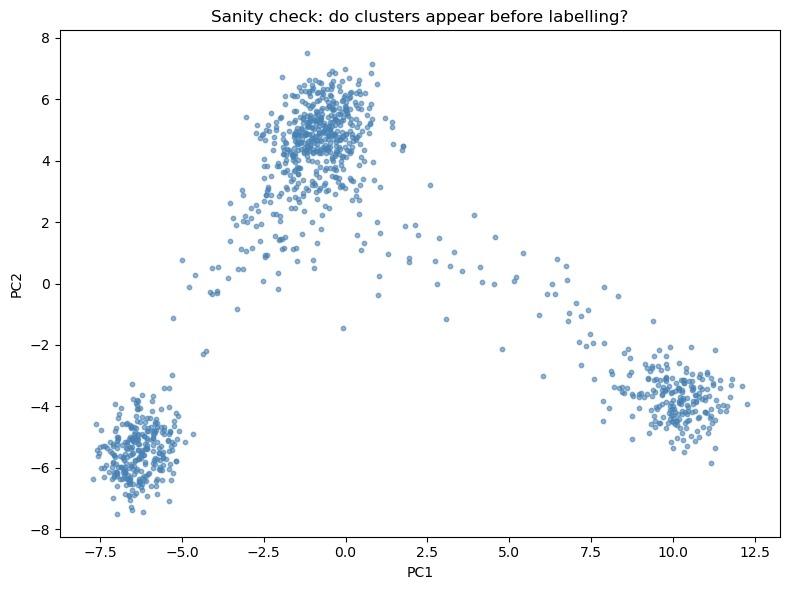

In [4]:
# Plain scatter before adding labels - just to verify clustering
plt.figure(figsize=(8,6))
plt.scatter(to_plot[:,0], to_plot[:,1], s=10, alpha=0.6, color='steelblue')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Sanity check: do clusters appear before labelling?')
plt.tight_layout()
plt.savefig('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_unlabelled.png', dpi=150)
plt.show()

## 5 - Building the Plotting DataFrame With Labels

In [5]:
# Small DataFrame: just metadata plus PC coordinates
df_plot = df[non_snp_cols].copy()
df_plot['PC1'] = to_plot[:, 0]
df_plot['PC2'] = to_plot[:, 1]

# Load population descriptions for super population names
pop = pd.read_csv('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/data/raw/igsr_populations.tsv', sep='\t')

# Merge on population code
df_plot = df_plot.merge(
    pop[['Population code', 'Superpopulation name', 'Population name']],
    on='Population code', how='left'
)

print(df_plot['Superpopulation name'].unique())
df_plot.head()

<ArrowStringArray>
[  'European Ancestry', 'East Asian Ancestry',   'American Ancestry',
    'African Ancestry']
Length: 4, dtype: str


,Sample,Population code,PC1,PC2,Superpopulation name,Population name
0,HG00096,GBR,0.312827,5.354349,European Ancestry,British
1,HG00097,GBR,-0.679403,6.183329,European Ancestry,British
2,HG00099,GBR,-0.420710,5.266720,European Ancestry,British
3,HG00100,GBR,-0.805419,5.965095,European Ancestry,British
4,HG00101,GBR,-0.771385,4.332076,European Ancestry,British


## 6 - The Headline Figure: PCA by Superpopulation

In [6]:
chart_super = alt.Chart(df_plot).mark_circle(size=40, opacity=0.75).encode(
    x=alt.X('PC1:Q', title='PC1'),
    y=alt.Y('PC2:Q', title='PC2'),
    color=alt.Color('Superpopulation name:N',
        scale=alt.Scale(scheme='tableau10'),
        legend=alt.Legend(title='Superpopulation')),
    tooltip=['Sample:N', 'Population name:N', 'Superpopulation name:N']
).properties(
    title={'text': 'Human Population Structure — 1000 Genomes Chr 22',
           'subtitle': 'PCA of ~5,000 SNPs from 1,092 individuals'},
    width=600, height=450
).interactive()  # enables pan and zoom

chart_super.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_superpopulation.html')
chart_super

alt.Chart(...)

## 7 - PCA by Individual Population

In [7]:
chart_pop = alt.Chart(df_plot).mark_circle(size=35, opacity=0.70).encode(
    x='PC1:Q', y='PC2:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category20'),
        legend=alt.Legend(title='Population', columns=2)),
    tooltip=['Sample:N', 'Population code:N', 'Population name:N',
             'Superpopulation name:N']
).properties(title='Structure by individual population',
    width=650, height=480).interactive()

chart_pop.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_population_codes.html')
chart_pop

alt.Chart(...)

## 8 - t-SNE Comparison

In [8]:
# t-SNE for visual comparison only (~2-5 minutes to run)
print('Running t-SNE...')
X_tsne = TSNE(
    n_components=2,
    learning_rate='auto',
    init='pca', # pca init is more stable than random
    random_state=42, # fix the seed for reproducibility
    perplexity=30 # default -- do NOT tune to get a 'nicer' plot
).fit_transform(matrix)

df_plot['tsne1'] = X_tsne[:,0]
df_plot['tsne2'] = X_tsne[:,1]

chart_tsne = alt.Chart(df_plot).mark_circle(size=40, opacity=0.75).encode(
    x='tsne1:Q', y='tsne2:Q',
    color=alt.Color('Superpopulation name:N',
        scale=alt.Scale(scheme='tableau10')),
    tooltip=['Sample:N', 'Population name:N']
).properties(title='t-SNE (perplexity=30) — compare with PCA',
    width=580, height=430).interactive()
 
chart_tsne.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/tsne_superpopulation.html')
chart_tsne

Running t-SNE...


alt.Chart(...)

## Saving Static PNG

In [9]:
import vl_convert as vlc

# Convert the superpopulation chart to a static PNG
png_bytes = vlc.vegalite_to_png(chart_super.to_json(), scale=2)
with open('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_superpopulation.png', 'wb') as f:
    f.write(png_bytes)
print('PNG saved for README.')

PNG saved for README.


## 9 - Side-Quest: SNP-PCA

SNP matrix shape: (4943, 1092)


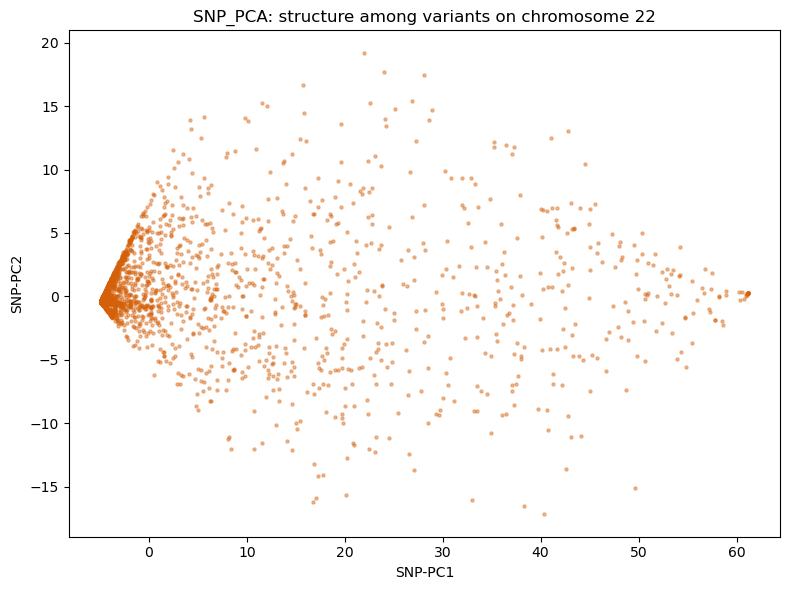

In [10]:
# Run PCA on the TRANSPOSED matrix (SNPs as rows)
matrix_T = matrix.T
print(f'SNP matrix shape: {matrix_T.shape}')

pca_snps = decomposition.PCA(n_components=2)
snp_coords = pca_snps.fit_transform(matrix_T)

plt.figure(figsize=(8,6))
plt.scatter(snp_coords[:, 0], snp_coords[:, 1],
            s=5, alpha=0.4, color='#D4600A')
plt.xlabel('SNP-PC1'); plt.ylabel('SNP-PC2')
plt.title('SNP_PCA: structure among variants on chromosome 22')
plt.tight_layout()
plt.savefig('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/snp_pca.png', dpi=150)
plt.show()

## 10 - Replicating Novembre er at. - European Subset

In [11]:
# Filter the plotting frame to Europeans only
eur_mask = df_plot['Superpopulation name'] == 'European Ancestry'
df_eur = df_plot[eur_mask].reset_index(drop=True)

# Extract the genotype rows for just the Europeans samples gotten
eur_samples = df_eur['Sample'].tolist()
eur_idx = [list(df['Sample']).index(s) for s in eur_samples]
matrix_eur = matrix[eur_idx, :]

# Run PCA on Europeans alone
pca_eur = decomposition.PCA(n_components=2)
eur_coords = pca_eur.fit_transform(matrix_eur)

print(f'European samples: {len(eur_samples)}')
print(f'PC1: {pca_eur.explained_variance_ratio_[0]*100:.3f}%, '
      f'PC2: {pca_eur.explained_variance_ratio_[1]*100:.3f}%')

European samples: 379
PC1: 1.464%, PC2: 1.314%


In [12]:
# Creating PCA Chart

df_eur = df_eur.copy()
df_eur['PC1'] = eur_coords[:, 0]
df_eur['PC2'] = eur_coords[:, 1]

chart_eur = alt.Chart(df_eur).mark_circle(size=50, opacity=0.8).encode(
    x='PC1:Q', y='PC2:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category20')),
    tooltip=['Sample:N', 'Population name:N']
).properties(
    title={'text': 'Within-European PCA — replicating Novembre 2008',
           'subtitle': 'Does European genetic structure mirror geography?'},
    width=580, height=430).interactive()

chart_eur.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_european_only.html')
chart_eur

alt.Chart(...)

## 11 - Building Africa-Only PCA

In [13]:
# Filter to African samples
afr_mask = df_plot['Superpopulation name'] == 'African Ancestry'
df_afr = df_plot[afr_mask].reset_index(drop=True)
 
afr_samples = df_afr['Sample'].tolist()
afr_idx = [list(df['Sample']).index(s) for s in afr_samples]
matrix_afr = matrix[afr_idx, :] 
 
print(f'African samples: {len(afr_samples)}')
print(df_afr['Population code'].value_counts())
 
# Run PCA with 3 components to see deeper structure
pca_afr = decomposition.PCA(n_components=3)
afr_coords = pca_afr.fit_transform(matrix_afr)
for i in range(3):
    print(f'PC{i+1}: {pca_afr.explained_variance_ratio_[i]*100:.3f}%')

African samples: 246
Population code
LWK    97
YRI    88
ASW    61
Name: count, dtype: int64
PC1: 1.913%
PC2: 1.387%
PC3: 1.185%


In [14]:
# Creating PC1 v PC2 chart

df_afr = df_afr.copy()
df_afr['PC1'] = afr_coords[:, 0]
df_afr['PC2'] = afr_coords[:, 1]
df_afr['PC3'] = afr_coords[:, 2]
 
chart_afr = alt.Chart(df_afr).mark_circle(size=55, opacity=0.8).encode(
    x='PC1:Q', y='PC2:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category10'),
        legend=alt.Legend(title='Population (Africa)')),
    tooltip=['Sample:N', 'Population name:N', 'Population code:N']
).properties(
    title={'text': 'Within-Africa PCA — 1000 Genomes AFR (PC1 v PC2)',
           'subtitle': 'YRI=Nigeria, LWK=Kenya, ASW=African-American'},
    width=600, height=450).interactive()
 
chart_afr.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_africa_pc1v2.html')
chart_afr


alt.Chart(...)

In [15]:
# Creating PC2 v PC3 chart

chart_afr_pc2v3 = alt.Chart(df_afr).mark_circle(size=50, opacity=0.8).encode(
    x='PC2:Q', y='PC3:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category10')),
    tooltip=['Sample:N', 'Population name:N']
).properties(
    title='Within-Africa PCA — PC2 vs PC3',
    width=580, height=430).interactive()

chart_afr_pc2v3.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_africa_pc2v3.html')
chart_afr_pc2v3

alt.Chart(...)

In [16]:
# Creating PC1 v PC3 chart

chart_afr_pc1v3 = alt.Chart(df_afr).mark_circle(size=55, opacity=0.8).encode(
    x='PC1:Q', y='PC3:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category10')),
    tooltip=['Sample:N', 'Population name:N']
).properties(
    title='Within-Africa PCA — PC1 vs PC3',
    width=580, height=430).interactive()

chart_afr_pc1v3.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_africa_pc1v3.html')
chart_afr_pc1v3

alt.Chart(...)

#### PC3 Analysis
PC2 vs PC3 and PC1 vs PC3 plots confirm that PC3 carries no additional 
population separation signal beyond what PC1 and PC2 already show. 
The main within-Africa structure — admixture on PC1, West vs East Africa 
on PC2 — is fully captured in two dimensions.

## 12 - Diversity Comparison

In [17]:
# Compare within-group diversity: Africa vs Europe
# Higher std dev of allele counts = more genetic diversity
eur_diversity = np.std(matrix_eur, axis=0).mean()
afr_diversity = np.std(matrix_afr, axis=0).mean()

print('===DIVERSITY COMPARISON===')
print(f'European within-group variability: {eur_diversity:.4f}')
print(f'African within-group variability: {afr_diversity:.4f}')
print(f'Ratio (AFR / EUR): {afr_diversity/eur_diversity:.3f}x')

===DIVERSITY COMPARISON===
European within-group variability: 0.1367
African within-group variability: 0.1955
Ratio (AFR / EUR): 1.430x


In [18]:
# Create a Bar chart to display and compare African vs European within-group diversity

# Build a small dataframe for Altair
df_diversity = pd.DataFrame({
    'Population': ['European', 'African'],
    'Diversity': [eur_diversity, afr_diversity],
    'Description': [
        f'n≈{len(eur_samples)} samples',
        f'n≈{len(afr_samples)} samples'
    ]
})

chart_diversity = alt.Chart(df_diversity).mark_bar(
    cornerRadiusTopLeft=4,
    cornerRadiusTopRight=4
).encode(
    x=alt.X('Population:N',
        axis=alt.Axis(labelFontSize=13, titleFontSize=14),
        title=None),
    y=alt.Y('Diversity:Q',
        title='Mean allele-count std dev',
        scale=alt.Scale(zero=True),
        axis=alt.Axis(labelFontSize=11, titleFontSize=13)),
    color=alt.Color('Population:N',
        scale=alt.Scale(
            domain=['European', 'African'],
            range=['#1A3A5C', '#D4600A']),
        legend=None),
    tooltip=[
        alt.Tooltip('Population:N', title='Population'),
        alt.Tooltip('Diversity:Q', title='Diversity', format='.4f'),
        alt.Tooltip('Description:N', title='Samples')
    ]
).properties(
    title=alt.TitleParams(
        text='Within-Group Genetic Diversity',
        subtitle='Higher value = more genetic variation within the population',
        fontSize=16,
        subtitleFontSize=12,
        subtitleColor='gray'
    ),
    width=350,
    height=400
)

# Add a text label on top of each bar showing the actual value of the within-group variability
text = chart_diversity.mark_text(
    align='center',
    baseline='top',
    dy=8,
    fontSize=12,
    fontWeight='bold'
).encode(
    text=alt.Text('Diversity:Q', format='.4f'),
    color=alt.value('white')
)

final_chart = (chart_diversity + text)

final_chart.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/diversity_comparison.html')

# Save PNG for README
import vl_convert as vlc
png_bytes = vlc.vegalite_to_png(final_chart.to_json(), scale=2)
with open('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/diversity_comparison.png', 'wb') as f:
    f.write(png_bytes)

final_chart

alt.LayerChart(...)

## Side-Quests: Ancestry-Informative Markers (AIMs) Analysis
 
Having established that global population structure is encoded in our
~5,000 chromosome 22 variants, we now ask: which specific variants
are doing the work? Are all variants contributing equally to the
clustering we see, or is the signal concentrated in a small subset?
 
We use two complementary approaches: distance from origin in SNP-PCA
space, and direct calculation of Fst. We then test whether the
top-ranked AIMs alone can recover global population structure.



## S1: Method 1 - Calculating Distance in SNP-PCA Space

In [19]:
# ====================================================================
# METHOD 1: Rank variants by distance in SNP-PCA space
# ====================================================================

variant_ids = list(df_snps.columns)
print(f'Number of variants: {len(variant_ids)}')

# Re-run SNP-PCA (transpose so variants are rows, people are columns)
matrix_T = matrix.T
print(f'SNP matrix shape (variants x samples): {matrix_T.shape}')

pca_snps = decomposition.PCA(n_components=2)
snp_coords = pca_snps.fit_transform(matrix_T)

# Build a DataFrame with each variant's SNP-PCA coordinates
df_snps_pca = pd. DataFrame({
    'variant_id': variant_ids,
    'snp_pc1': snp_coords[:, 0],
    'snp_pc2': snp_coords[:, 1]
})

# Distance from origin = how much this variant deviates from 
# average behaviour. Use Pythagorean theorem: sqrt(PC1^2 + PC2^2)
df_snps_pca['distance_from_origin'] = np.sqrt(
    df_snps_pca['snp_pc1']**2 + df_snps_pca['snp_pc2']**2
)

# Sort by distance, show top 20
top_aims_pca = df_snps_pca.sort_values('distance_from_origin',
                                       ascending=False)
print("\n=== Top 20 AIMs by SNP-PCA distance ===")
print(top_aims_pca.head(20).to_string(index=False))

Number of variants: 4943
SNP matrix shape (variants x samples): (4943, 1092)

=== Top 20 AIMs by SNP-PCA distance ===
 variant_id   snp_pc1   snp_pc2  distance_from_origin
  rs5755454 61.137666  0.239022             61.138133
  rs2032113 61.137666  0.239022             61.138133
   rs738908 61.137666  0.239022             61.138133
 rs67984003 61.137666  0.239022             61.138133
rs138353993 61.137666  0.239022             61.138133
  rs6001322 61.137666  0.239022             61.138133
 rs60783417 61.137666  0.239022             61.138133
  rs2793076 61.137666  0.239022             61.138133
  rs2899172 61.077561  0.135809             61.077712
  rs6006705 61.016519  0.053098             61.016542
  rs1633415 60.990866  0.180958             60.991134
   rs910539 60.745714 -0.237069             60.746177
 rs59226544 60.604124  0.375905             60.605290
   rs132172 60.362079 -0.265129             60.362661
 rs56680580 60.259317  0.345826             60.260310
   rs423923 58.898

## S2: Method 2 - Direct Fst Calculation

In [20]:
# ====================================================================
# METHOD 2: Calculate Fst for every variant (vectorised)
# ====================================================================
# Fst = variance in allele frequency BETWEEN populations
#       divided by total variance
# Higher Fst = variant differs more between populations = more ancestry-informative

# Get population labels in the same order as matrix rows
pop_labels = df['Population code'].values
populations = np.unique(pop_labels)
print(f'Number of populations: {len(populations)}')
print(f'Populations: {populations}')

# Build allele frequency table: rows = populations, cols = variants
# pop_freqs[i, j] = allele frequency of vaariant j in population i
pop_freqs = np.zeros((len(populations), matrix.shape[1]))
pop_sizes = np.zeros(len(populations))

for i, pops in enumerate(populations):
    mask = pop_labels == pops
    pop_genos = matrix[mask, :]
    pop_freqs[i, :] = pop_genos.sum(axis=0) / (2 * mask.sum())
    pop_sizes[i] = mask.sum()

# Overall allele frequency (weighted by population size)
total_freq = (pop_freqs.T @ pop_sizes) / pop_sizes.sum()

# Between-population variance (weighted by population size)
weights = pop_sizes / pop_sizes.sum()
between_var = ((pop_freqs - total_freq) ** 2).T @ weights

# Total variance = p * (1 - p), with safeguard against division by zero
total_var = total_freq * (1 - total_freq)
safe_total_var = np.where(total_var > 0, total_var, 1)
fst_values = np.where(total_var > 0, between_var / safe_total_var, 0)

print(f'\nFst calculation complete.')
print(f'Mean Fst:         {fst_values.mean():.4f}')
print(f'Median Fst:       {np.median(fst_values):.4f}')
print(f'Max Fst:          {fst_values.max():.4f}')
print(f'Variants Fst>0.1: {(fst_values > 0.1).sum()}')
print(f'Variants Fst>0.3: {(fst_values > 0.3).sum()}')
print(f'Variants Fst>0.5: {(fst_values > 0.5).sum()}')

Number of populations: 14
Populations: ['ASW' 'CEU' 'CHB' 'CHS' 'CLM' 'FIN' 'GBR' 'IBS' 'JPT' 'LWK' 'MXL' 'PUR'
 'TSI' 'YRI']

Fst calculation complete.
Mean Fst:         0.0334
Median Fst:       0.0152
Max Fst:          0.4751
Variants Fst>0.1: 392
Variants Fst>0.3: 20
Variants Fst>0.5: 0


## S3: Visualizing the AIMs

In [21]:
# Fst Distribution visualization
df_aims = pd.DataFrame({
    'variant_id': variant_ids,
    'fst': fst_values,
    'snp_pc1_distance': df_snps_pca['distance_from_origin'].values
})

# Histogram of Fst values
chart_fst_hist = alt.Chart(df_aims).mark_bar(
    color='#D4600A',
    opacity=0.8
).encode(
    x=alt.X('fst:Q',
        bin=alt.Bin(maxbins=60),
        title='Fst (between-population differentiation)'),
    y=alt.Y('count():Q', title='Number of variants'),
    tooltip=[alt.Tooltip('count():Q', title='Variants in bin')]
).properties(
    title=alt.TitleParams(
        text='Distribution of Fst across chromosome 22 variants',
        subtitle='Most variants are shared across populations (low Fst); a small tail are strong AIMs'
    ),
    width=600, height=350
)

# Add reference lines at Fst = 0.1 and Fst = 0.3
rule_low = alt.Chart(pd.DataFrame({'x': [0.1]})).mark_rule(
    color='#1A3A5C', strokeDash=[6, 4]
).encode(x='x:Q')
 
rule_high = alt.Chart(pd.DataFrame({'x': [0.3]})).mark_rule(
    color='#1A3A5C', strokeDash=[6, 4]
).encode(x='x:Q')
 
(chart_fst_hist + rule_low + rule_high).save(
    '/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/'
    'results/figures/fst_distribution.html'
)
 
chart_fst_hist + rule_low + rule_high


alt.LayerChart(...)

In [22]:
# Scatter plot of Fst vs SNP-PCA distance
chart_methods_agreement = alt.Chart(df_aims).mark_circle(
    size=25, opacity=0.5, color='#1A3A5C'
).encode(
    x=alt.X('snp_pc1_distance:Q', title='SNP-PCA distance from origin'),
    y=alt.Y('fst:Q', title='Fst'),
    tooltip=['variant_id:N',
             alt.Tooltip('fst:Q', format='.3f'),
             alt.Tooltip('snp_pc1_distance:Q', format='.2f')]
).properties(
    title=alt.TitleParams(
        text='Do both AIM identification methods agree?',
        subtitle='Partial agreement (r=0.344); Fst is more specific, SNP-PCA captures additional LD structure'
    ),
    width=600, height=400
).interactive()
 
# Compute Pearson correlation for the README
corr = df_aims[['fst', 'snp_pc1_distance']].corr().iloc[0, 1]
print(f'Pearson correlation (Fst vs SNP-PCA distance): {corr:.3f}')
 
chart_methods_agreement.save(
    '/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/'
    'results/figures/fst_vs_pca_distance.html'
)
chart_methods_agreement


Pearson correlation (Fst vs SNP-PCA distance): 0.344


alt.Chart(...)

In [23]:
# Extracting the top 50 variants by Fst
N_TOP = 50
top_idx = np.argsort(fst_values)[::-1][:N_TOP]
matrix_aims = matrix[:, top_idx]

print(f'Running PCA on top {N_TOP} AIMs only')
print(f'Matrix shape (samples x AIMs): {matrix_aims.shape}')

pca_aims = decomposition.PCA(n_components=2)
aims_coords = pca_aims.fit_transform(matrix_aims)

print(f'\nVariance explained:')
print(f'  PC1: {pca_aims.explained_variance_ratio_[0]*100:.2f}%')
print(f'  PC2: {pca_aims.explained_variance_ratio_[1]*100:.2f}%')
print(f'  Total (PC1+PC2): '
      f'{sum(pca_aims.explained_variance_ratio_)*100:.2f}%')


Running PCA on top 50 AIMs only
Matrix shape (samples x AIMs): (1092, 50)

Variance explained:
  PC1: 36.04%
  PC2: 12.57%
  Total (PC1+PC2): 48.61%


In [24]:
# Plotting PCA Chart of AIMs

df_aims_pca = df[['Sample', 'Population code']].copy()
df_aims_pca['PC1'] = aims_coords[:, 0]
df_aims_pca['PC2'] = aims_coords[:, 1] * -1 # Flip PC2 sign to match original PCA orientation - purely cosmetic, not scientific
df_aims_pca = df_aims_pca.merge(
    pop[['Population code', 'Superpopulation name', 'Population name']],
    on='Population code', how='left'
)
 
chart_aims_pca = alt.Chart(df_aims_pca).mark_circle(
    size=40, opacity=0.75
).encode(
    x=alt.X('PC1:Q', title='PC1'),
    y=alt.Y('PC2:Q', title='PC2'),
    color=alt.Color('Superpopulation name:N',
        scale=alt.Scale(scheme='tableau10'),
        legend=alt.Legend(title='Superpopulation')),
    tooltip=['Sample:N', 'Population code:N',
             'Population name:N', 'Superpopulation name:N']
).properties(
    title=alt.TitleParams(
        text=f'PCA using only the top {N_TOP} AIMs',
        subtitle=f'Population structure recovered from {N_TOP} of '
                 f'{matrix.shape[1]} variants ({100*N_TOP/matrix.shape[1]:.1f}%)'
    ),
    width=600, height=450
).interactive()
 
chart_aims_pca.save(
    '/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/'
    'results/figures/pca_top50_aims.html'
)

# Save a static PNG for the README
import vl_convert as vlc
png_bytes = vlc.vegalite_to_png(chart_aims_pca.to_json(), scale=2)
with open('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/'
          'results/figures/pca_top50_aims.png', 'wb') as f:
    f.write(png_bytes)
 
chart_aims_pca

alt.Chart(...)

## Side Quest 2: Creating Streamlit App

### Preparing small dataset for the app

In [25]:
# ====================================================================
# Export precomputed data for the Streamlit app
# ====================================================================
import os
os.makedirs('streamlit_app/data', exist_ok=True)
 
# Per-sample table: global PCA, European PCA, African PCA, AIMs PCA, t-SNE
df_app = df[['Sample', 'Population code']].copy()
df_app = df_app.merge(pop[['Population code', 'Superpopulation name',
                            'Population name']], on='Population code',
                       how='left')
 
# Global PCA coordinates (from earlier in notebook)
df_app['pc1_global'] = to_plot[:, 0]
df_app['pc2_global'] = to_plot[:, 1]
 
# t-SNE coordinates
df_app['tsne1'] = X_tsne[:, 0]
df_app['tsne2'] = X_tsne[:, 1]
 
# AIMs PCA coordinates (with the cosmetic PC2 flip already applied)
df_app['pc1_aims'] = aims_coords[:, 0]
df_app['pc2_aims'] = aims_coords[:, 1] * -1
 
# European subset coords (only filled for European samples)
df_app['pc1_eur'] = np.nan
df_app['pc2_eur'] = np.nan
df_app.loc[df_app['Sample'].isin(eur_samples), 'pc1_eur'] = eur_coords[:, 0]
df_app.loc[df_app['Sample'].isin(eur_samples), 'pc2_eur'] = eur_coords[:, 1]
 
# African subset coords (only filled for African samples)
df_app['pc1_afr'] = np.nan
df_app['pc2_afr'] = np.nan
df_app['pc3_afr'] = np.nan
df_app.loc[df_app['Sample'].isin(afr_samples), 'pc1_afr'] = afr_coords[:, 0]
df_app.loc[df_app['Sample'].isin(afr_samples), 'pc2_afr'] = afr_coords[:, 1]
df_app.loc[df_app['Sample'].isin(afr_samples), 'pc3_afr'] = afr_coords[:, 2]
 
df_app.to_csv('streamlit_app/data/samples.csv', index=False)
print(f'Saved samples.csv ({len(df_app)} rows)')
 
# Per-variant Fst table (top 200 by Fst, more than enough for the app)
top200_idx = np.argsort(fst_values)[::-1][:200]
df_fst = pd.DataFrame({
    'variant_id': [variant_ids[i] for i in top200_idx],
    'fst': fst_values[top200_idx],
    'snp_pc1_distance': df_snps_pca['distance_from_origin'].iloc[top200_idx].values
})
df_fst.to_csv('streamlit_app/data/top_aims.csv', index=False)
print(f'Saved top_aims.csv ({len(df_fst)} rows)')
 
# Pre-computed AIMs PCAs for different N values (lets the slider be instant)
import json
aims_pcas = {}
for n in [10, 25, 50, 100, 200]:
    idx = np.argsort(fst_values)[::-1][:n]
    pca_n = decomposition.PCA(n_components=2)
    coords = pca_n.fit_transform(matrix[:, idx])
    aims_pcas[str(n)] = {
        'pc1': coords[:, 0].tolist(),
        'pc2': (coords[:, 1] * -1).tolist(),
        'var_pc1': float(pca_n.explained_variance_ratio_[0] * 100),
        'var_pc2': float(pca_n.explained_variance_ratio_[1] * 100)
    }
with open('streamlit_app/data/aims_pcas.json', 'w') as f:
    json.dump(aims_pcas, f)
print('Saved aims_pcas.json for N in [10, 25, 50, 100, 200]')
 
# Diversity metric and overall stats — a tiny JSON of headline numbers
stats = {
    'n_samples': int(len(df)),
    'n_variants': int(matrix.shape[1]),
    'n_populations': int(df['Population code'].nunique()),
    'n_superpopulations': int(df_app['Superpopulation name'].nunique()),
    'eur_diversity': float(eur_diversity),
    'afr_diversity': float(afr_diversity),
    'diversity_ratio': float(afr_diversity / eur_diversity),
    'mean_fst': float(fst_values.mean()),
    'max_fst': float(fst_values.max()),
    'n_fst_above_0_1': int((fst_values > 0.1).sum()),
    'n_fst_above_0_3': int((fst_values > 0.3).sum()),
    'pc1_full_var': float(pca.explained_variance_ratio_[0] * 100),
    'pc2_full_var': float(pca.explained_variance_ratio_[1] * 100),
    'methods_correlation': 0.344  # from our earlier print
}
with open('streamlit_app/data/stats.json', 'w') as f:
    json.dump(stats, f, indent=2)
print('Saved stats.json')


Saved samples.csv (1092 rows)
Saved top_aims.csv (200 rows)
Saved aims_pcas.json for N in [10, 25, 50, 100, 200]
Saved stats.json
